<a href="https://colab.research.google.com/github/LaimengEung/inf-604-data-analysis-i-repo/blob/master/Copy_of_Lab5_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TP5 - EDA: Correlation Analysis**

**Course**: **INF-604: Data Analysis** <br>
**Lecturer**: **Sothea HAS, PhD**

-----

**Objective:** In this lab, you will apply correaltion analysis on real examples. We will also explore the limitations of correaltion analysis and what to watch out when drawing

- You can work directly with `Google Colab` here: [Lab5_EDA.ipynb](https://colab.research.google.com/drive/11JYPdo76e1FPVvm47zDJ5yYI-yzxDuyu?usp=sharing).


-----


In [1]:
# %pip install gapminder           # This is for installing the package
from gapminder import gapminder
import pandas as pd
import numpy as np
gapminder.head()


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Note: you may need to restart the kernel to use updated packages.


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


# 1. Pearson and Spearman's correlations

**a.** Compute Pearson correlation matrix of the three quantitative variables on year $1952$, $1987$ and then $2007$ using `pd.corr()`. Give a brief intuition of the relationship between these variables.

In [2]:
data1952 = gapminder.query("year == 1952")
data1987 = gapminder.query("year == 1987")
data2007 = gapminder.query("year == 2007")

# 1952
data1952.iloc[:, -3:].corr().style.background_gradient()

,lifeExp,pop,gdpPercap
lifeExp,1.000000,-0.002725,0.278024
pop,-0.002725,1.000000,-0.025260
gdpPercap,0.278024,-0.025260,1.000000


In [3]:
# 1987
data1987.iloc[:, -3:].corr().style.background_gradient()

,lifeExp,pop,gdpPercap
lifeExp,1.000000,0.033062,0.749905
pop,0.033062,1.000000,-0.051705
gdpPercap,0.749905,-0.051705,1.000000


In [4]:
# 2007
data2007.iloc[:, -3:].corr().style.background_gradient()

,lifeExp,pop,gdpPercap
lifeExp,1.000000,0.047553,0.678662
pop,0.047553,1.000000,-0.055676
gdpPercap,0.678662,-0.055676,1.000000


> Description: Back in the past (1952), more GDP doesn't really translate to better helth conditions. Rich country may have low life expectancy, and vice versa. However, this seems to change in coming years, when gdpPercap and lifeExp seems to have high correlation between each other (as shown in the 1987 and 2007 table). <br> <br>
> #### P.S. After doing spearman's, this is due to outliers only. (Because of one extreme outlier, Kuwait, it **destroys** the information completely) lmaoo... <br>
> However, it is important to not rush to the conclusion, you gotta study (analyse) the Spearman's correlation or log scaled the outlier's column first


,lifeExp,pop,gdpPercap,gdpPercap_scaled
lifeExp,1.000000,-0.002725,0.278024,0.747781
pop,-0.002725,1.000000,-0.025260,-0.107255
gdpPercap,0.278024,-0.025260,1.000000,0.575526
gdpPercap_scaled,0.747781,-0.107255,0.575526,1.000000


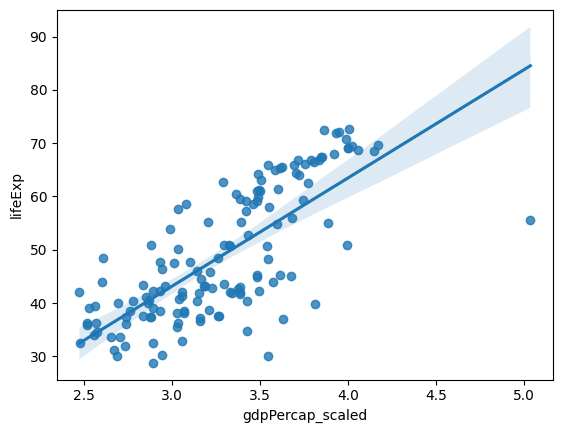

In [5]:
import seaborn as sns
import numpy as np

data1952_log = data1952.copy()
data1952_log['gdpPercap_scaled'] = np.log10(data1952['gdpPercap'])
sns.regplot(data1952_log, x='gdpPercap_scaled', y='lifeExp')

data1952_log.iloc[:, -4:].corr().style.background_gradient()

<Axes: xlabel='gdpPercap', ylabel='lifeExp'>

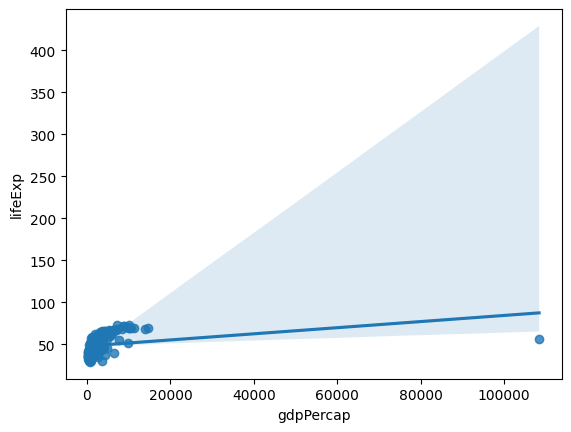

In [6]:
sns.regplot(data1952, x='gdpPercap', y='lifeExp')

**b.** Compute Spearman's Rank Correlation of the previous columns in 1952, 1987 and 2007. What do you observe?

In [7]:
# To do
data1952.iloc[:, -3:].corr(method='spearman').style.background_gradient()

,lifeExp,pop,gdpPercap
lifeExp,1.000000,0.175466,0.768701
pop,0.175466,1.000000,0.086571
gdpPercap,0.768701,0.086571,1.000000


In [8]:
data1987.iloc[:, -3:].corr(method='spearman').style.background_gradient()

,lifeExp,pop,gdpPercap
lifeExp,1.000000,0.053419,0.892465
pop,0.053419,1.000000,0.008355
gdpPercap,0.892465,0.008355,1.000000


In [9]:
data2007.iloc[:, -3:].corr(method='spearman').style.background_gradient()

,lifeExp,pop,gdpPercap
lifeExp,1.000000,0.003355,0.856590
pop,0.003355,1.000000,-0.064588
gdpPercap,0.856590,-0.064588,1.000000


> After Computing the Spearman's Rank Correlation of the previous columns, we can see that in **1952**, `gdpPercap` and `lifeExp` does in fact have strong correlation, of **0.77** compared to Pearson's Correlation of just **0.28**.

> This clearly shows the flaw of the Pearson Correlation Coefficient due to **extreme outliers**.

**c.** From the previous result, pick the most interesting pair of variables and plot a graphic illustrating their relationship for each year using proper axis scaling and title.

Correlation in 1952 (Scaled): 0.75
Correlation in 1987 (Scaled): 0.87
Correlation in 2007 (Scaled): 0.81


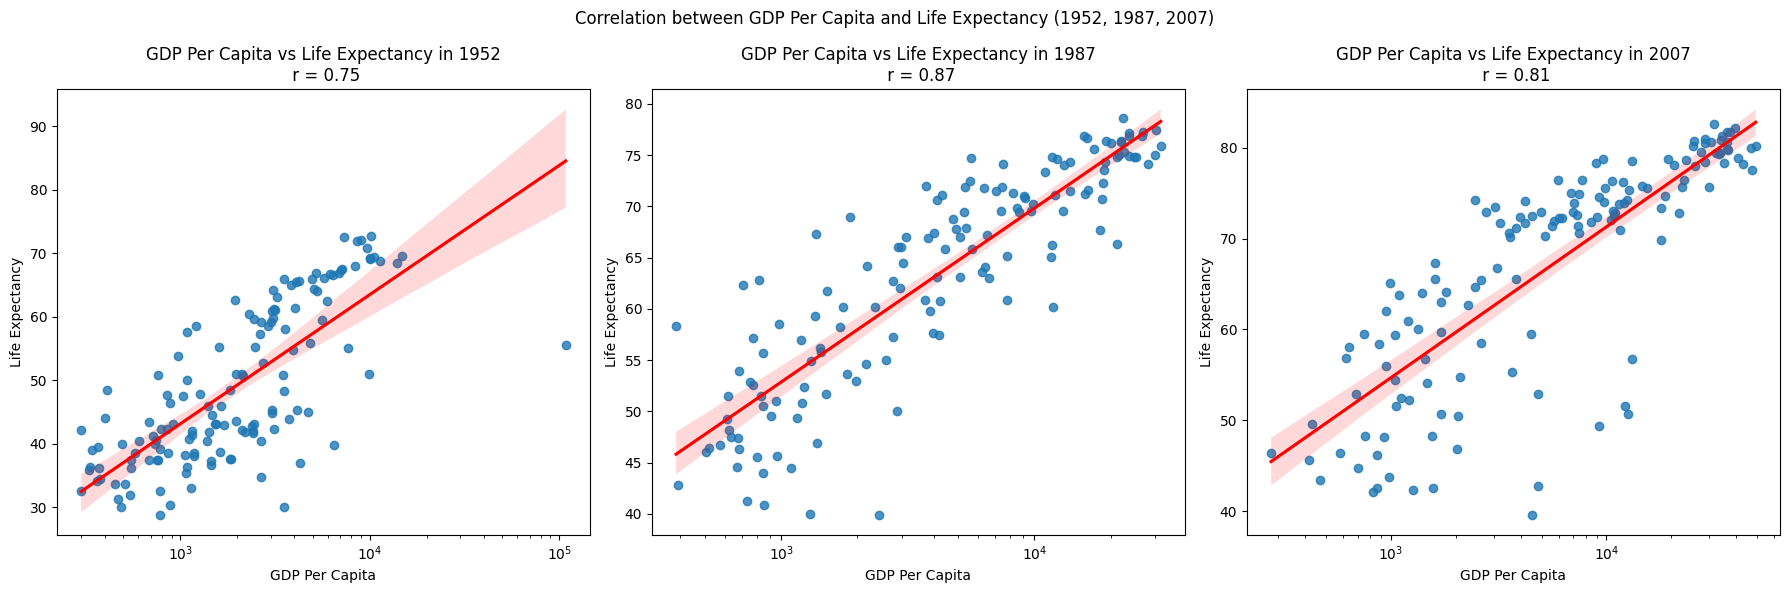

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# To do
datasets = [data1952, data1987, data2007]
years = [1952, 1987, 2007]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, data, year in zip(axes, datasets, years):
    sns.regplot(
        data=data,
        x='gdpPercap',
        y='lifeExp',
        ax=ax,
        logx=True,
        line_kws={
            'color': 'red'
        }
    )

    pearson_r = np.log10(data.gdpPercap).corr(data.lifeExp)

    ax.set_xscale("log")
    ax.set_title(f"GDP Per Capita vs Life Expectancy in {year}\n r = {pearson_r:.2f}")
    ax.set_xlabel("GDP Per Capita")
    ax.set_ylabel("Life Expectancy")
    print(f"Correlation in {year} (Scaled): {pearson_r:.2f}")

plt.suptitle("Correlation between GDP Per Capita and Life Expectancy (1952, 1987, 2007)")
plt.tight_layout()

Correlation in 1952 (Spearman): 0.77
Correlation in 1987 (Spearman): 0.89
Correlation in 2007 (Spearman): 0.86


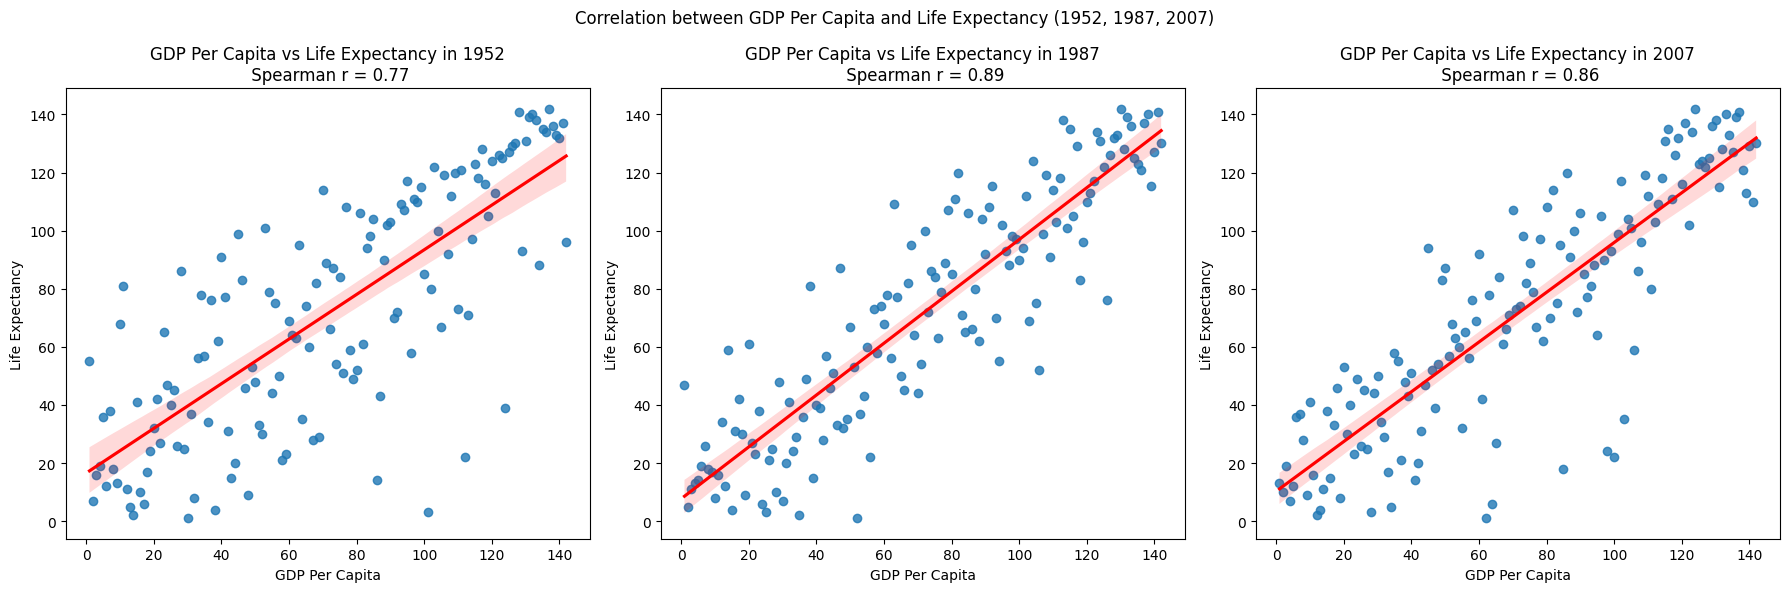

In [77]:
import scipy.stats as stats     # import stats to find r of Spearman

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, data, year in zip(axes, datasets, years):
    ranked_data = pd.DataFrame(     # create a new df for just ranked data
        {
            'gdpPercap_rank': data['gdpPercap'].rank(),     # pandas' method to get rank
            'lifeExp_rank': data['lifeExp'].rank()
        }
    )

    sns.regplot(
        data=ranked_data,
        x='gdpPercap_rank',
        y='lifeExp_rank',
        ax=ax,
        line_kws={'color': 'red'}
    )

    spearman_r, _ = stats.spearmanr(ranked_data['gdpPercap_rank'], ranked_data['lifeExp_rank'])
    # .spearmanr returns 2 values (statistic (the actual r) and pvalue); we only want statistic (the acutal Spearman's r)

    # ax.set_xscale("log") # no need to scale anymore
    ax.set_title(f"GDP Per Capita vs Life Expectancy in {year}\n Spearman r = {spearman_r:.2f}")
    ax.set_xlabel("GDP Per Capita")
    ax.set_ylabel("Life Expectancy")
    print(f"Correlation in {year} (Spearman): {spearman_r:.2f}")

plt.suptitle("Correlation between GDP Per Capita and Life Expectancy (1952, 1987, 2007)")
plt.tight_layout()    
     

**d.** Revisit your intuition of the correlation matrix in year 1952 from question **(a)**, can you see why we observed such a (poor) correlation in 1952?!

- Now, drop the weird country of year 1952. Revisualize and recompute the correaltion between `health` and `economy` condition of the world in 1952. Conclude.

> **Remark:** Pearson correlation matrix can summarize linear relationship between pairs of quantitative variables but it might be inacurate and influenced by

> - outliers,
> - non-linearity,
> - small sample size,
> - confounding (causal) variables...

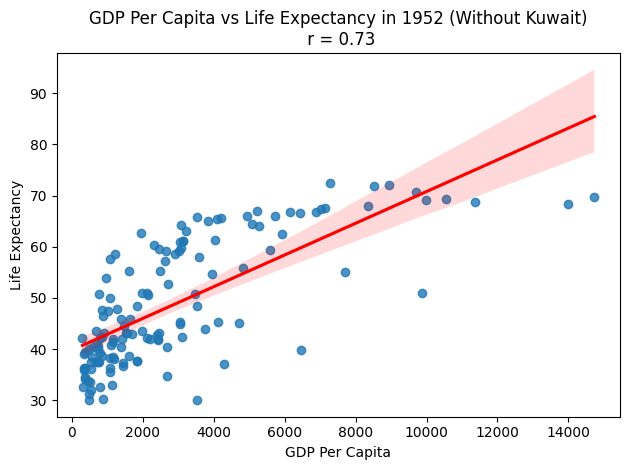

In [92]:
# Revisualize 1952 data after dropping the weird country 

data1952_wo_kw = data1952.drop(index=data1952.idxmax(axis=0)) # .idxmax: finds the index of the max value of a specified axis

sns.regplot(
    data=data1952_wo_kw,
    x='gdpPercap',
    y='lifeExp',
    line_kws={'color': 'red'}
)

r = data1952_wo_kw.gdpPercap.corr(data1952_wo_kw.lifeExp)

plt.xlabel("GDP Per Capita")
plt.ylabel("Life Expectancy")
plt.title(f"GDP Per Capita vs Life Expectancy in 1952 (Without Kuwait)\n r = {r:.2f}")
plt.tight_layout()
plt.show()

> After removing the extreme outlier country, the Pearson's R increased significantly!

# 2. $\eta$-squared correlations

**a.** We have seen how life expectancy and economy vary across continents in 1952 ([Lab4](https://hassothea.github.io/Data_Analysis_AUPP/Labs/Lab4_Data_Visualization.html)) and 2007 ([course](https://hassothea.github.io/Data_Analysis_AUPP/Slides/Data_Visualization.html#/bivariate-visualization-4)).

- Compute $\eta$-squared correlation between `continent` and `lifeExp` then `continent` with `gdpPercap` in 1952, 1987 and 2007 (before and after removing the weird country in 1952).

- Do you find the results reasonable? Explain.

In [121]:
# eta-squared correlation between continent and lifeExp (4 correlations) (Quan. vs Qual.)
# eta-squared correlation = BSS (Between Sum of Squares) / TSS (Total Sum of Squares)

import pingouin as pg     
# Lessgoooooo, another animal library; pingouin :D, It is built on top of Pandas and NumPy
# pingouin is a statistical package used for statistical analyses
# It can automatically calculate the eta-squared correlation
# another way, we can archieve it is trough manually calculating BSS and TSS, then divide them

aov_table = pg.anova(
    data=data1952_wo_kw, 
    dv='lifeExp',           # dependent variable: it is considered the "effect" or outcome in a study; typically plotted on the y-axis of a graph
    between='continent',    # the between-subject factor(s); in our case, the groups are continents (5 different independent groups)
    effsize='np2'            # n2: eta-squared, np2: partial eta-squared       
    # In our case, since it's a One-Way ANOVA (meaning that there is only one independent variable with multiple groups), np2 is the same as n2
)

print("Eta-Sqaured Correlation between continent and lifeExp in 1952 Without Kuwait")
print(aov_table)

Eta-Sqaured Correlation between continent and lifeExp in 1952 Without Kuwait
      Source  ddof1  ddof2          F         p-unc       np2
0  continent      4    131  61.574318  3.544435e-29  0.652794


In [123]:
print("Eta-Sqaured Correlation between continent and lifeExp\n")

for data, year in zip(datasets, years):
    aov_table = pg.anova(
        data=data,
        dv='lifeExp',
        between='continent',
        effsize='np2'
    )
    print(f"Eta-Squared Correlation in {year}: {aov_table['np2'].values.item():.2f}") 
    # type(aov_table): DataFrame
    # type(aov_table['np2'].values): ndarray (aov_table['np2'] is Series ofc)
    # type(aov_table['np2'].values.item():): to get the items of the ndarray -> ndarray's dtype

Eta-Sqaured Correlation between continent and lifeExp

Eta-Squared Correlation in 1952: 0.65
Eta-Squared Correlation in 1987: 0.59
Eta-Squared Correlation in 2007: 0.64


In [124]:
print("Eta-Sqaured Correlation between continent and gdpPercap\n")

for data, year in zip(datasets, years):
    aov_table = pg.anova(
        data=data,
        dv='gdpPercap',
        between='continent',
        effsize='np2'
    )
    print(f"Eta-Squared Correlation in {year}: {aov_table['np2'].values.item():.2f}") 

Eta-Sqaured Correlation between continent and gdpPercap

Eta-Squared Correlation in 1952: 0.05
Eta-Squared Correlation in 1987: 0.47
Eta-Squared Correlation in 2007: 0.42


<iframe src="https://hassothea.github.io/Data_Analysis_AUPP/Slides/EDA.html#/eta-squared-coefficient-2" width="500" height="300"></iframe> 

> $$BSS = \sum_{g=1}^{G} n_g \cdot (\bar{x}_g - \bar{x})^2$$
> $$TSS = \sum_{i=1}^{n} (x_i - \bar{x})^2$$

In [133]:
# Manually calculating BSS and TSS
global_mean = data1952_wo_kw['gdpPercap'].mean()

e_data = data1952_wo_kw.copy()
# Sum of (n_g * (mean_g - global_mean)^2) for each group g of G (continents)
BSS = sum(
    e_data[e_data['continent'] == g]['gdpPercap'].count()                       # n_g: total number of observations within group g of G (we count all the occurences for each group)
    * (e_data[e_data['continent'] == g]['gdpPercap'].mean() - global_mean)**2   # (mean_g - global_mean)**2 (mean_g: mean of X over a group g of G -> we find the mean of all the occurences for each group)
    for g in e_data['continent'].unique()                                       # for g in G
)

# Sum of (x_i - global_mean)^2 for all observations i
TSS = sum(
    (e_data['gdpPercap'] - global_mean)**2                                      # (each individual observation - global mean of all oberservations)^2
)

eta_squared = BSS / TSS

print(f"Eta-Sqaured Correlation between continent and gdpPercap in 1952 without Kuwait: \neta-squared = {eta_squared:.2f}")

Eta-Sqaured Correlation between continent and gdpPercap in 1952 without Kuwait: 
eta-squared = 0.41


In [ ]:
# Let's do an AOV table just to check
aov_table_1952_wo_kw = pg.anova(
    data=e_data,
    dv='gdpPercap',
    between='continent',
    effsize='np2'
)
print(f"eta-squared: {aov_table_1952_wo_kw.np2.values.item():.2f}")
# yayyyyyyyy, it's the same

eta-squared: 0.41


> ##### Results: YEP! The result is reasonable. for `lifeExp`, the $\eta$-squared correlation doesn't seem to be much of a different between the years, and before and after removing the extreme outlier, staying at about (~0.54 - 0.65).
> ##### However, for `gdpPercap`, the $\eta$-squared correlation between before and after is way different, it jumps from 0.05 to 0.41. This is due to the fact that the the weird country stretches out too far, inflating the global mean, which increases the `TSS`. After removing Kuwait, TSS shrinks back to quite normal.

| year | dv | between | np2 |
|---|---|---|---|
| 1952 | lifeExp | continent | 0.65 |
| 1952 (after) | lifeExp | continent | 0.65 |
| 1987 | lifeExp | continent | 0.59 | 
| 2007 | lifeExp | continent | 0.54 |
|---|---|---|---|
| 1952 | gdpPercap | continent | **0.05** |
| 1952 (after) | gdpPercap | continent | **0.41** |
| 1987 | gdpPercap | continent | 0.47 |
| 2007 | gdpPercap | continent | 0.42 |

# 3. Time evolution

**a.** Draw the evolution of the following correaltions from 1952 to 2007:

- `Person` and `Spearman` corerlation between life expectancy and GDP per capita
- $\eta$-squared coefficients of continent vs life expectancy, and continents vs GDP per capita.

---------

> The following graph is expected.

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# figs = make_subplots(rows=3, cols=1)
years = gapminder['']
# First, init lists to store the correlations (3 correlations)


# fig = px.line(
#     data_frame=
# )

**b.** Fom what you have studied about Gapminder dataset, describe the world from 1952 to 2007.

> Description:

# Further readings
- Gapminder documentation: [https://www.gapminder.org/data/documentation/](https://www.gapminder.org/data/documentation/)
- A short demonstration video is available here: [Hans Rosling's 200 Countries, 200 Years, 4 Minutes - The Joy of Stats - BBC Four](https://youtu.be/jbkSRLYSojo?si=qipg08VIi999hEgo).
- Graphical tools:
    - [`matplotlib`](https://matplotlib.org/stable/index.html)
    - [`seaborn`](https://seaborn.pydata.org/)
    - [`plotly`](https://plotly.com/python/)